# Analysis of the ALADIN results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
# === GLOBAL HIGH-CONTRAST PALETTE ===
COLOR_PALETTE = [
    "#1a80bb",  # strong blue
    "#ea801c",  # vivid orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
]

FONTS = {
    "title": 18,
    "label": 16,
    "ticks": 14,
    "legend": 14,
}

DEFAULT_FIGSIZE = (12, 4)

## Implementation analysis

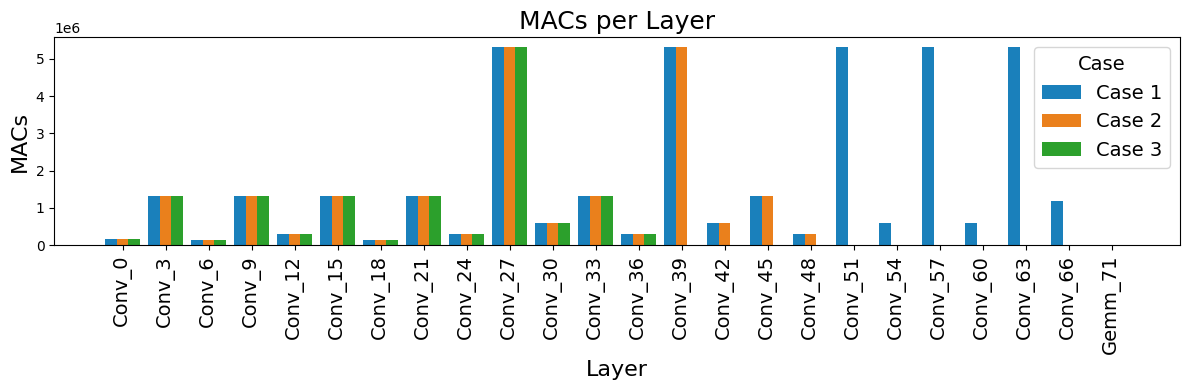

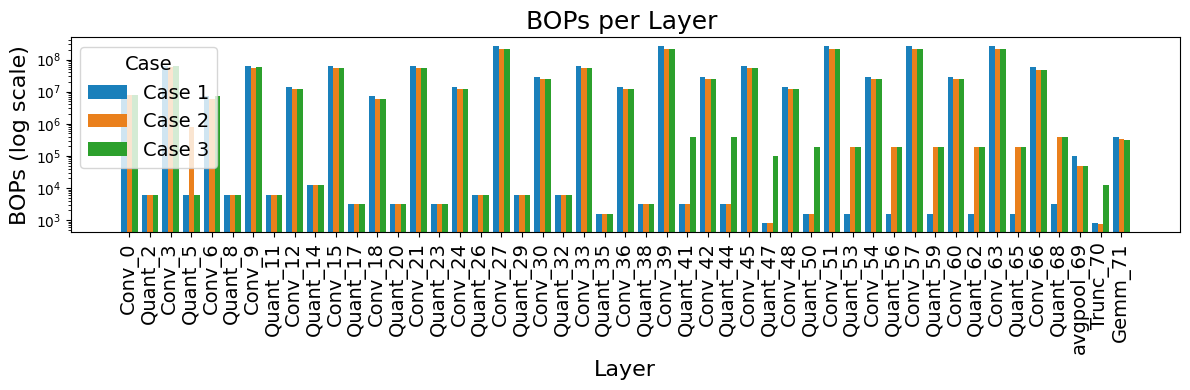

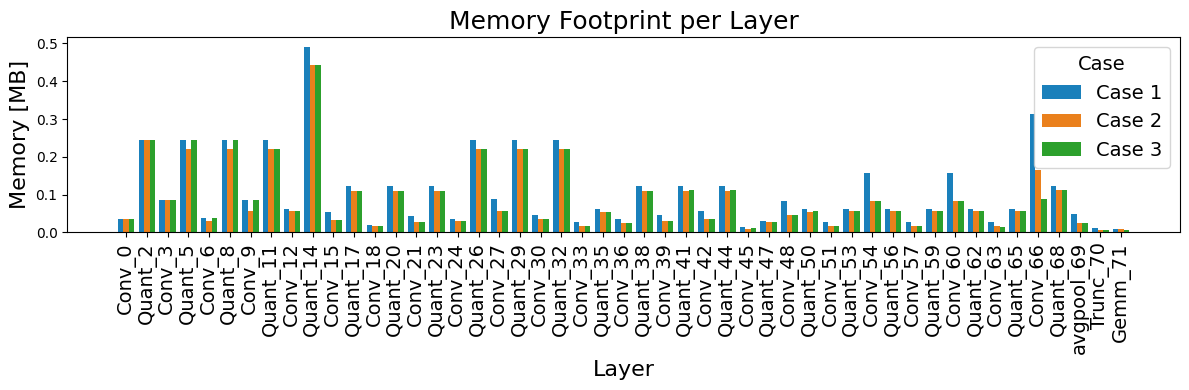

In [3]:
# ============================================================================
# DATA PREPARATION FUNCTIONS
# ============================================================================

def load_and_prepare_data(file_path):
    """Load CSV and create base configuration labels."""
    df = pd.read_csv(file_path)
    df['config'] = df.apply(
        lambda x: f"Cores: {x['num_cores']} L1: {x['L1_mem']//1000} kB L2: {x['L2_mem']//1000} kB",
        axis=1
    )
    return df


def clean_layer_names(df, layer_col="Layers"):
    """Standardize layer names (e.g., GlobalAveragePool_ → avgpool_)."""
    df = df.copy()
    df[layer_col] = df[layer_col].str.replace(r"^GlobalAveragePool_", "avgpool_", regex=True)
    return df


def filter_layers(df, exclude_pattern=None, value_col=None):
    """
    Filter out layers matching a pattern and/or rows with zero values.
    
    Parameters:
    - df: DataFrame
    - exclude_pattern: Regex pattern to exclude layers (e.g., "Relu")
    - value_col: Column name; if provided, remove rows where value == 0
    """
    df = df.copy()
    
    if exclude_pattern:
        df = df[~df["Layers"].str.contains(exclude_pattern, case=False, na=False)]
    
    if value_col and value_col in df.columns:
        df = df[df[value_col] != 0]
    
    return df


def convert_memory_units(df, memory_col="Memory", target_unit="kB"):
    """Convert memory values to target unit."""
    df = df.copy()
    conversion_factors = {
        "kB": 1 / 1000.0,
        "MB": 1 / 1_000_000.0,
        "Bytes": 1.0,
    }
    
    if target_unit in conversion_factors:
        new_col = f"{memory_col}_{target_unit}"
        df[new_col] = df[memory_col] * conversion_factors[target_unit]
    
    return df


def aggregate_by_layer_and_param(df, compare_by, value_col):
    """Group data by layer and a specific parameter, returning mean values."""
    df_grouped = df.groupby(['Layers', compare_by], as_index=False)[value_col].mean()
    return df_grouped


def align_cases(df, value_col, compare_by, layer_col="Layers"):
    """
    Align all cases by the CSV order of layers, fill missing with 0.
    
    Returns:
    - layers: Ordered list of unique layers
    - cases: Sorted list of unique comparison values
    - aligned: List of DataFrames, one per case with aligned layers
    """
    layers = list(dict.fromkeys(df[layer_col]))
    cases = sorted(df[compare_by].unique())

    aligned = []
    for c in cases:
        subset = df[df[compare_by] == c][[layer_col, value_col]]
        subset = subset.set_index(layer_col).reindex(layers, fill_value=0).reset_index()
        subset["Case"] = c
        aligned.append(subset)

    return layers, cases, aligned


def create_pivot_table(df, index_col, columns_col, values_col, max_configs=None):
    """Create and optionally limit a pivot table."""
    pivot = df.pivot(
        index=index_col,
        columns=columns_col,
        values=values_col
    ).reindex(index=pd.unique(df[index_col]))
    
    if max_configs:
        pivot = pivot.iloc[:, :max_configs]
    
    return pivot


# ============================================================================
# PLOTTING HELPER FUNCTIONS
# ============================================================================

def _get_colors(n):
    """Cycle through the palette for n cases."""
    return [COLOR_PALETTE[i % len(COLOR_PALETTE)] for i in range(n)]


def _setup_bar_plot(n_items, n_groups, figsize=DEFAULT_FIGSIZE):
    """Create figure and calculate bar positioning parameters."""
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(n_items)
    width = 0.8 / max(1, n_groups)
    return fig, ax, x, width


def _plot_grouped_bars(ax, x, aligned_data, width, colors, value_col, layer_col="Layers"):
    """Plot grouped bars for multiple cases."""
    for i, subset in enumerate(aligned_data):
        case_label = str(subset["Case"].iloc[0])
        ax.bar(
            x + i * width,
            subset[value_col],
            width=width,
            label=case_label,
            color=colors[i],
        )


def _plot_single_bars(ax, df, x_col, y_col, color=None):
    """Plot a single series of bars."""
    if color is None:
        color = COLOR_PALETTE[0]
    ax.bar(df[x_col], df[y_col], color=color)


def _configure_axes(ax, layers, xlabel, ylabel, title, compare_by=None, 
                    log_scale=False, n_groups=1):
    """Set labels, ticks, and formatting for the plot."""
    width = 0.8 / max(1, n_groups)
    x = np.arange(len(layers))
    
    ax.set_xticks(x + width * (n_groups - 1) / 2)
    ax.set_xticklabels(layers, rotation=90, fontsize=FONTS["ticks"])
    ax.set_xlabel("Layer", fontsize=FONTS["label"])
    ax.set_ylabel(ylabel, fontsize=FONTS["label"])
    ax.set_title(title, fontsize=FONTS["title"])
    
    if log_scale:
        ax.set_yscale("log")
    
    if compare_by:
        ax.legend(title=compare_by, fontsize=FONTS["legend"], title_fontsize=FONTS["legend"])
    
    plt.tight_layout()


# ============================================================================
# METRIC-SPECIFIC PLOTTING FUNCTIONS
# ============================================================================

def plot_macs(file_path, dst_path, compare_by=None):
    """
    Plot MACs per layer, optionally comparing across cases.
    
    Parameters:
    - file_path: Path to CSV with columns [Layers, MACs, and compare_by]
    - dst_path: Output file path
    - compare_by: Column name to group by (e.g., "Case"); None for single bar chart
    """
    df = pd.read_csv(file_path)
    df = filter_layers(df, value_col="MACs")
    df = clean_layer_names(df)
    
    plt.style.use("default")
    
    if compare_by and compare_by in df.columns:
        layers, cases, aligned = align_cases(df, "MACs", compare_by)
        fig, ax, x, width = _setup_bar_plot(len(layers), len(cases))
        colors = _get_colors(len(cases))
        
        _plot_grouped_bars(ax, x, aligned, width, colors, "MACs")
        _configure_axes(ax, layers, "Layer", "MACs", 
                       "MACs per Layer", 
                       compare_by=compare_by, n_groups=len(cases))
    else:
        fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
        _plot_single_bars(ax, df, "Layers", "MACs")
        ax.set_xticklabels(df["Layers"], rotation=90, fontsize=FONTS["ticks"])
        ax.set_ylabel("MACs", fontsize=FONTS["label"])
        ax.set_title("MACs per Layer", fontsize=FONTS["title"])
        plt.tight_layout()
    
    plt.show()
    plt.close(fig)


def plot_bops(file_path, dst_path, compare_by=None):
    """
    Plot BOPs per layer (log scale), optionally comparing across cases.
    Excludes ReLU layers by default.
    
    Parameters:
    - file_path: Path to CSV with columns [Layers, BOPs, and compare_by]
    - dst_path: Output file path
    - compare_by: Column name to group by (e.g., "Case"); None for single bar chart
    """
    df = pd.read_csv(file_path)
    df = filter_layers(df, exclude_pattern="Relu", value_col="BOPs")
    df = clean_layer_names(df)
    
    plt.style.use("default")
    
    if compare_by and compare_by in df.columns:
        layers, cases, aligned = align_cases(df, "BOPs", compare_by)
        fig, ax, x, width = _setup_bar_plot(len(layers), len(cases))
        colors = _get_colors(len(cases))
        
        _plot_grouped_bars(ax, x, aligned, width, colors, "BOPs")
        _configure_axes(ax, layers, "Layer", "BOPs (log scale)", 
                       "BOPs per Layer ", 
                       compare_by=compare_by, log_scale=True, n_groups=len(cases))
    else:
        fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
        _plot_single_bars(ax, df, "Layers", "BOPs")
        ax.set_xticklabels(df["Layers"], rotation=90, fontsize=FONTS["ticks"])
        ax.set_yscale("log")
        ax.set_ylabel("BOPs", fontsize=FONTS["label"])
        ax.set_title("BOPs per Layer", fontsize=FONTS["title"])
        plt.tight_layout()
    
    plt.show()
    plt.close(fig)


def plot_memory(file_path, dst_path, compare_by=None, unit="kB"):
    """
    Plot memory footprint per layer, optionally comparing across cases.
    Excludes ReLU layers by default.
    
    Parameters:
    - file_path: Path to CSV with columns [Layers, Memory, and compare_by]
    - dst_path: Output file path
    - compare_by: Column name to group by (e.g., "Case"); None for single bar chart
    - unit: Target unit for memory ("kB", "MB", "B")
    """
    df = pd.read_csv(file_path)
    df = filter_layers(df, exclude_pattern="Relu", value_col="Memory")
    df = clean_layer_names(df)
    df = convert_memory_units(df, memory_col="Memory", target_unit=unit)
    
    memory_col = f"Memory_{unit}"
    
    plt.style.use("default")
    
    if compare_by and compare_by in df.columns:
        layers, cases, aligned = align_cases(df, memory_col, compare_by)
        fig, ax, x, width = _setup_bar_plot(len(layers), len(cases))
        colors = _get_colors(len(cases))
        
        _plot_grouped_bars(ax, x, aligned, width, colors, memory_col)
        _configure_axes(ax, layers, "Layer", f"Memory [{unit}]", 
                       "Memory Footprint per Layer", 
                       compare_by=compare_by, n_groups=len(cases))
    else:
        fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
        _plot_single_bars(ax, df, "Layers", memory_col)
        ax.set_xticklabels(df["Layers"], rotation=90, fontsize=FONTS["ticks"])
        ax.set_ylabel(f"Memory [{unit}]", fontsize=FONTS["label"])
        ax.set_title("Memory Footprint per Layer", fontsize=FONTS["title"])
        plt.tight_layout()
    
    plt.show()
    plt.close(fig)


# ============================================================================
# USAGE EXAMPLES
# ============================================================================

plot_macs("results/profile.csv", "macs_comparison.png", compare_by="Case")

plot_bops("results/profile.csv", "bops_comparison.png", compare_by="Case")

plot_memory("results/profile.csv", "memory_comparison.png", compare_by="Case", unit="MB")

## Implementation Analysis

In [4]:

def load_and_prepare_data(file_path):
    df = pd.read_csv(file_path)
    df["config"] = df.apply(
        lambda x: f"Cores: {x['num_cores']}  L1: {x['L1_mem']//1000} kB  L2: {x['L2_mem']//1000} kB",
        axis=1,
    )
    return df


def _fmt_label(val, col):
    if col in ("L1_mem", "L2_mem"):
        return f"{int(val)//1000} kB"
    return str(val)


def _sort_layers(layers):
    """Sort layers by trailing number; FC/dense layers go last."""
    fc_keywords = ("fullyconnected", "fc", "gemm", "linear", "dense", "matmul")

    def key(name):
        is_fc = name.lower().startswith(fc_keywords)
        m = re.search(r"(\d+)$", name)
        num = int(m.group(1)) if m else -1
        return (1 if is_fc else 0, num, name)

    return sorted(layers, key=key)


def _abbrev_layer(name):
    """Keep only uppercase letters + trailing number: ReluConvolution3 -> RC3."""
    letters = "".join(c for c in name if c.isupper())
    m = re.search(r"(\d+)$", name)
    return letters + (m.group(1) if m else "")


def _aggregate(df, compare_by):
    return df.groupby(["layer_name", compare_by], as_index=False)["num_cycles"].mean()


def _pivot(df_grouped, compare_by, max_configs=None):
    ordered_layers = _sort_layers(df_grouped["layer_name"].unique())
    piv = df_grouped.pivot(index="layer_name", columns=compare_by, values="num_cycles")
    piv = piv.reindex(ordered_layers)
    if max_configs:
        piv = piv.iloc[:, :max_configs]
    return piv


def _tiling_pivot(df, tiling_col, compare_by, max_configs=None):
    """Return a pivot of mean tiling values per (layer, compare_by)."""
    grp = df.groupby(["layer_name", compare_by], as_index=False)[tiling_col].mean()
    grp[tiling_col] = grp[tiling_col] / 1000
    ordered_layers = _sort_layers(grp["layer_name"].unique())
    piv = grp.pivot(index="layer_name", columns=compare_by, values=tiling_col)
    piv = piv.reindex(ordered_layers)
    if max_configs:
        piv = piv.iloc[:, :max_configs]
    return piv


# ── plot helpers ─────────────────────────────────────────────────────────────

def _bar_layout(n_layers, n_configs):
    fig_width = max(10, n_layers * 0.35)
    fig, ax = plt.subplots(figsize=(fig_width, 6))
    x = np.arange(n_layers)
    width = 0.8 / max(1, n_configs)
    return fig, ax, x, width


def _draw_bars(ax, x, pivot, width, labels, fill_nan=0.0):
    for i, col in enumerate(pivot.columns):
        y = np.nan_to_num(pivot[col].values, nan=fill_nan)
        ax.bar(x + i * width, y, width=width, label=labels[i],
               color=COLOR_PALETTE[i % len(COLOR_PALETTE)])


def _style_ax(ax, pivot, x, width, xlabel, ylabel, title, log_scale=False):
    n = len(pivot.columns)
    ax.set_xticks(x + width * (n - 1) / 2)
    ax.set_xticklabels([_abbrev_layer(l) for l in pivot.index], rotation=90, fontsize=FONTS["ticks"])
    ax.set_xlabel(xlabel, fontsize=FONTS["label"])
    ax.set_ylabel(ylabel, fontsize=FONTS["label"])
    ax.set_title(title, fontsize=FONTS["title"])
    ax.legend(title="", fontsize=FONTS["legend"], title_fontsize=FONTS["legend"])
    if log_scale:
        ax.set_yscale("log")


# ── public API ───────────────────────────────────────────────────────────────

PARAM_NAMES = {
    "num_cores": "Number of Cores",
    "L1_mem":    "L1 SRAM size",
    "L2_mem":    "L2 SRAM size",
    "Case": "Cases"
}


def plot_cycles(df, compare_by, dst_path=None, max_configs=None, fill_nan=0.0):
    """Bar chart of num_cycles per layer, grouped by compare_by."""
    grp  = _aggregate(df, compare_by)
    piv  = _pivot(grp, compare_by, max_configs)
    labels = [_fmt_label(c, compare_by) for c in piv.columns]

    fig, ax, x, w = _bar_layout(len(piv), len(piv.columns))
    _draw_bars(ax, x, piv, w, labels, fill_nan)
    _style_ax(ax, piv, x, w,
              xlabel="Layer",
              ylabel="Cycles (log scale)",
              title=f"Layer-wise Cycles by {PARAM_NAMES[compare_by]}",
              log_scale=True)
    plt.tight_layout()
    if dst_path:
        plt.savefig(dst_path, dpi=150)
    plt.show()
    plt.close(fig)



def plot_l1_tiling(df, compare_by, dst_path=None, max_configs=None):
    """Bar chart of L1_tiling per layer, grouped by compare_by."""
    piv    = _tiling_pivot(df, "L1_tiling", compare_by, max_configs)
    labels = [_fmt_label(c, compare_by) for c in piv.columns]
    fig, ax, x, w = _bar_layout(len(piv), len(piv.columns))
    _draw_bars(ax, x, piv, w, labels)
    _style_ax(ax, piv, x, w,
              xlabel="Layer",
              ylabel="Memeory Footprint [kB]",
              title=f"L1 Tiling per Layer by {PARAM_NAMES[compare_by]}")
    plt.tight_layout()
    if dst_path:
        plt.savefig(dst_path, dpi=150)
    plt.show()
    plt.close(fig)


def plot_l2_tiling(df, compare_by, dst_path=None, max_configs=None):
    """Bar chart of L2_tiling per layer, grouped by compare_by."""
    piv    = _tiling_pivot(df, "L2_tiling", compare_by, max_configs)
    labels = [_fmt_label(c, compare_by) for c in piv.columns]
    fig, ax, x, w = _bar_layout(len(piv), len(piv.columns))
    _draw_bars(ax, x, piv, w, labels)
    _style_ax(ax, piv, x, w,
              xlabel="Layer",
              ylabel="Memory Footprint [kB]",
              title=f"L2 Tiling per Layer by {PARAM_NAMES[compare_by]}")
    plt.tight_layout()
    if dst_path:
        plt.savefig(dst_path, dpi=150)
    plt.show()
    plt.close(fig)


In [5]:
df = pd.read_csv("results/perf_analysis.csv")
df.head

<bound method NDFrame.head of        Case         layer_name    MACs  num_cycles  MAC_per_cycle  num_cores  \
0    Case 1   ReluConvolution0  165888       46998       3.529682          8   
1    Case 1   ReluConvolution1   55296       42558       1.299309          8   
2    Case 1   ReluConvolution2  147456       29957       4.922255          8   
3    Case 1   ReluConvolution3   55296       42522       1.300409          8   
4    Case 1   ReluConvolution4  294912       54555       5.405774          8   
..      ...                ...     ...         ...            ...        ...   
670  Case 3  ReluConvolution20       0     4698630       0.000000          2   
671  Case 3  ReluConvolution21       0      143441       0.000000          2   
672  Case 3  ReluConvolution22       0     9426877       0.000000          2   
673  Case 3      ReluPooling23       0       23119       0.000000          2   
674  Case 3   FullyConnected24       0       78730       0.000000          2   

     L1_m

### Comparison between different cases

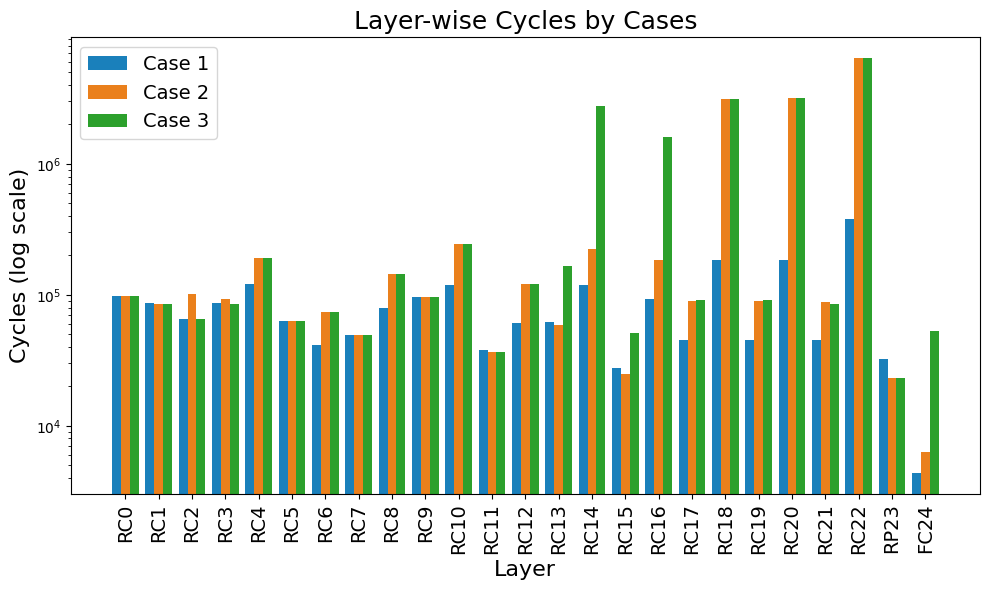

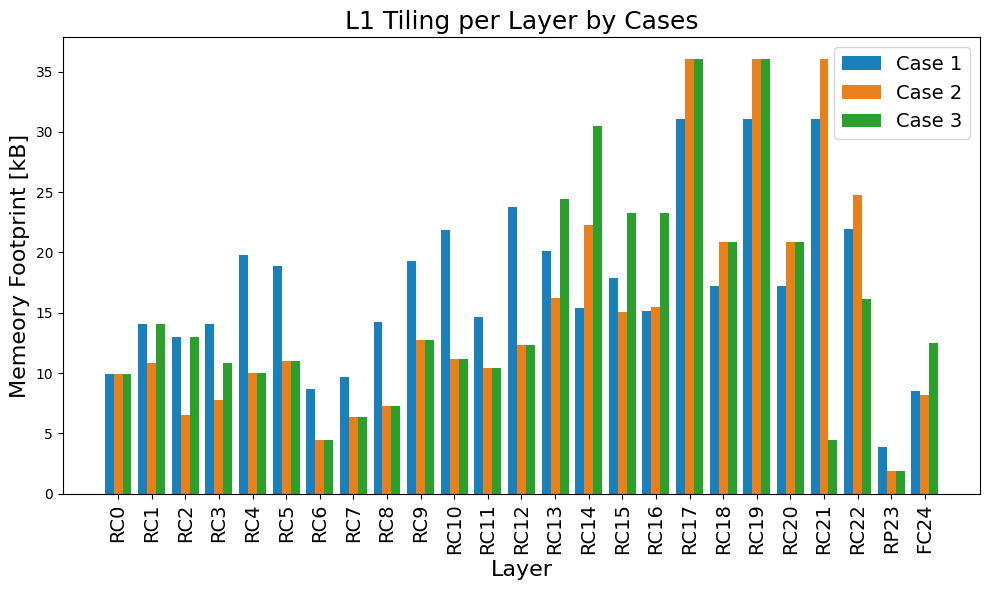

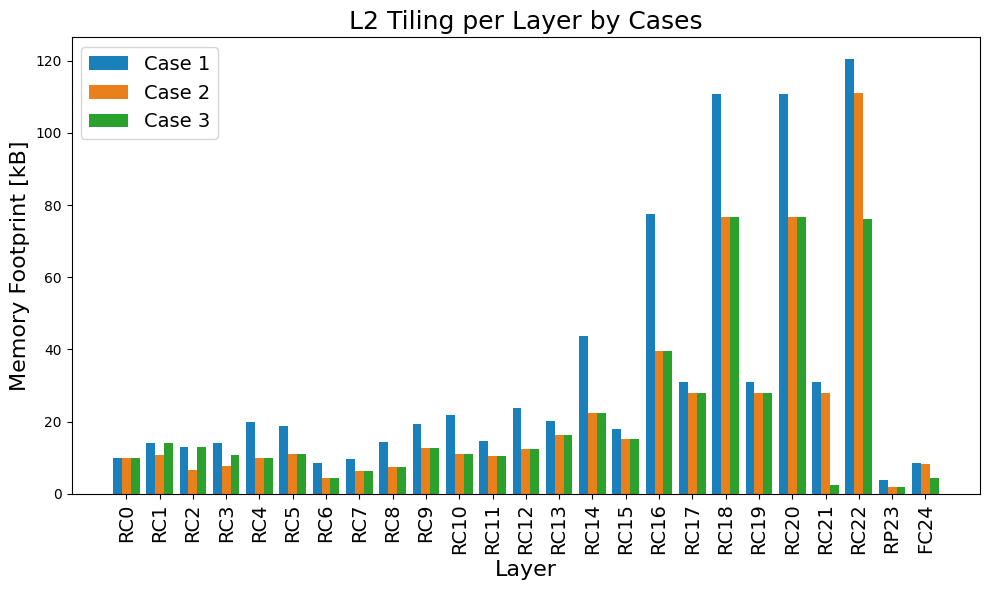

In [6]:
plot_cycles(df, 'Case')
plot_l1_tiling(df, "Case")
plot_l2_tiling(df, "Case")

### HW-codesign

In [7]:
df_case_2 = df[df["Case"] == "Case 2"]
df_case_2

,Case,layer_name,MACs,num_cycles,MAC_per_cycle,num_cores,L1_mem,L2_mem,L1_tiling,L2_tiling
225,Case 2,ReluConvolution0,165888,46942,3.533893,8,64000,256000,9960.0,9960.0
226,Case 2,ReluConvolution1,55296,50287,1.099608,8,64000,256000,10860.0,10860.0
227,Case 2,ReluConvolution2,147456,44929,3.281978,8,64000,256000,6528.0,6528.0
228,Case 2,ReluConvolution3,55296,53938,1.025177,8,64000,256000,7788.0,7788.0
229,Case 2,ReluConvolution4,294912,83783,3.519950,8,64000,256000,9984.0,9984.0
...,...,...,...,...,...,...,...,...,...,...
445,Case 2,ReluConvolution20,0,4647102,0.000000,2,64000,512000,20840.0,76800.0
446,Case 2,ReluConvolution21,0,148713,0.000000,2,64000,512000,36032.0,27840.0
447,Case 2,ReluConvolution22,0,9442475,0.000000,2,64000,512000,20048.0,152832.0
448,Case 2,ReluPooling23,0,23028,0.000000,2,64000,512000,1920.0,1920.0


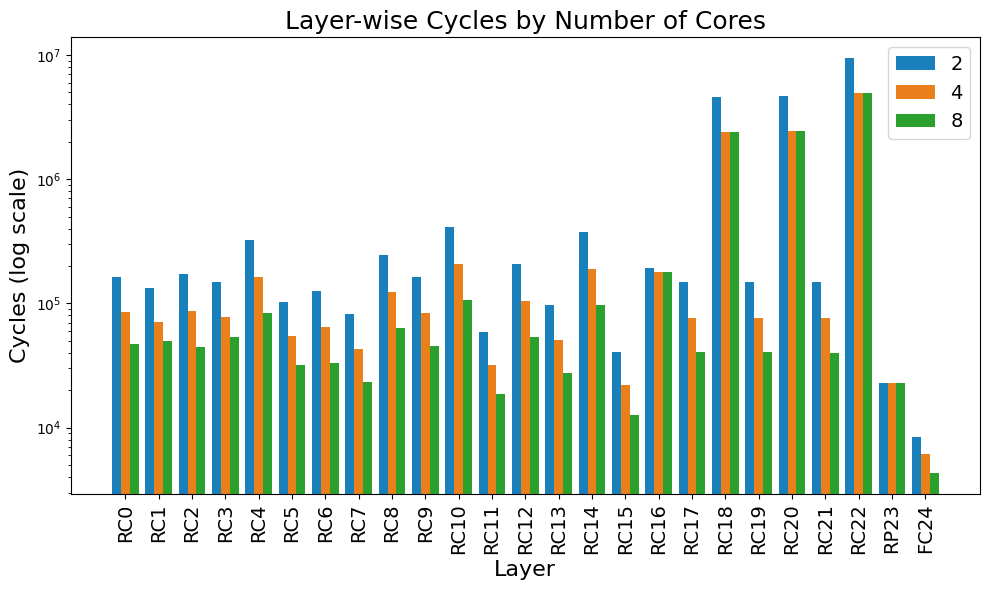

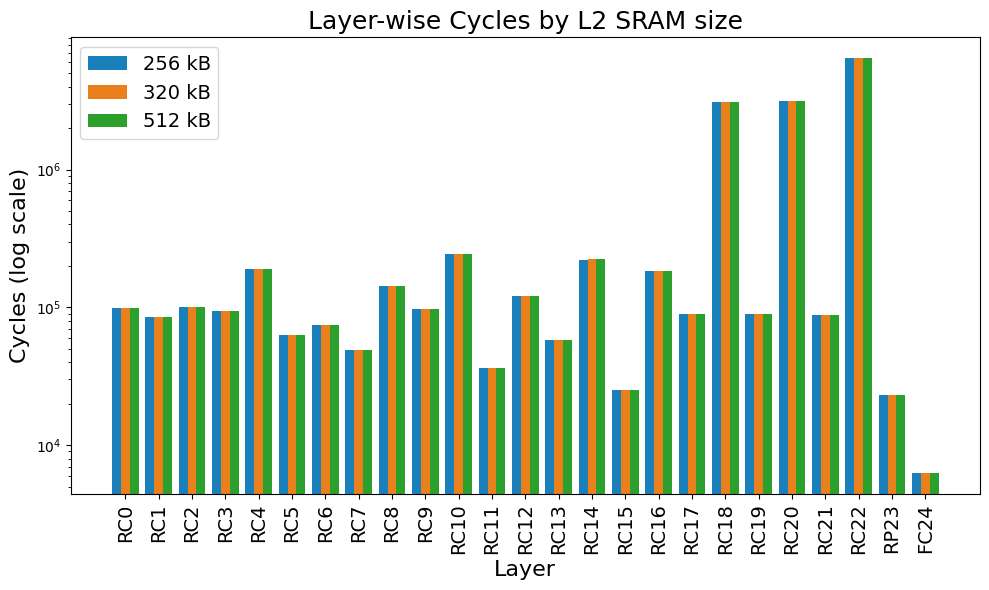

In [8]:
plot_cycles(df_case_2, 'num_cores')
plot_cycles(df_case_2, 'L2_mem')

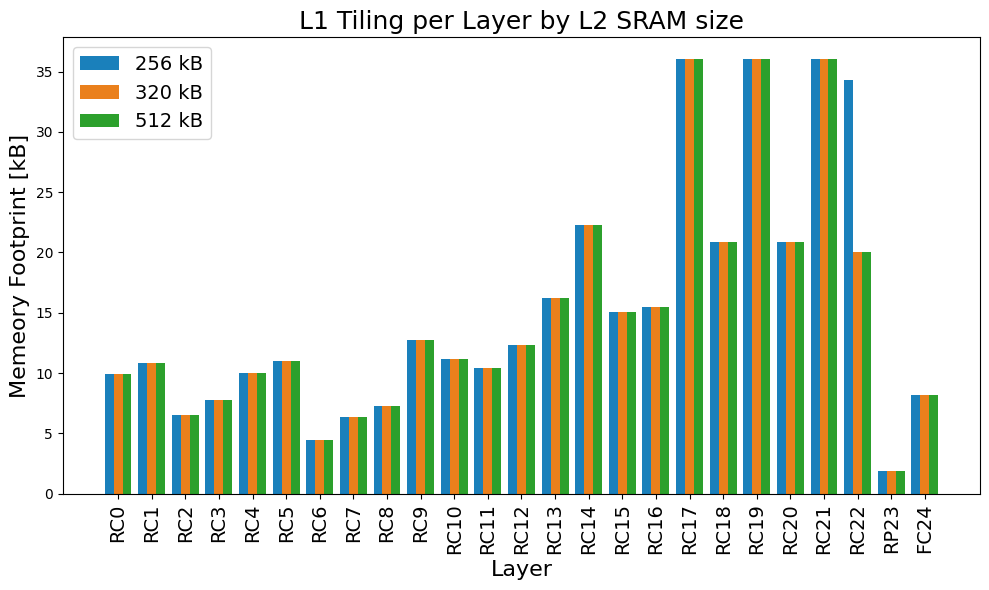

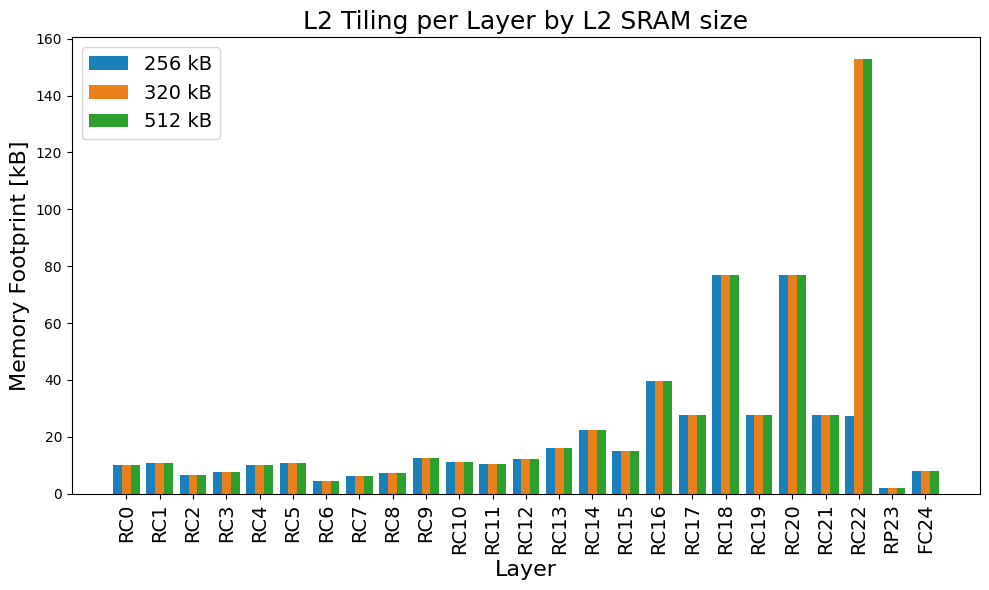

In [9]:
plot_l1_tiling(df_case_2, "L2_mem")
plot_l2_tiling(df_case_2, "L2_mem")